# Simple autoencoder using jax and equinox

## Explanation of imports


In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

## Loading the data using torchvision

In [7]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

trainloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

https://docs.kidger.site/equinox/examples/mnist/

In [8]:
def torch_batch_to_jax(x):
    """Convert torch tensor batch to JAX array."""
    return jnp.asarray(x.detach().cpu().numpy(), dtype=jnp.float32)

In [16]:
key = jax.random.PRNGKey(0)

X_example, y_example = next(iter(trainloader))
input_shape = tuple(X_example[0].shape) 

## AutoEncoder class

In [42]:
class AutoEncoder(eqx.Module):
    

    class Encoder(eqx.Module):
        layers: list

        def __init__(self, key, input_shape):
            in_features = math.prod(input_shape)
            key1 , key2 , key3 = jax.random.split(key,3)
            self.layers = [
                jnp.ravel,
                eqx.nn.Linear(in_features, 256, key=key1),
                jax.nn.sigmoid,
                eqx.nn.Linear(256 , 128 , key = key2),
                jax.nn.sigmoid,
                eqx.nn.Linear(128, 2 , key = key3)
            ]

        def __call__(self, x):
            for layer in self.layers:
                x = layer(x)
            return x
    
    
    
    class Decoder(eqx.Module):
        layers:list
        output_shape:tuple

        def __init__(self,key, input_shape):
            out_features = math.prod(input_shape)
            self.output_shape = input_shape
            key1 , key2 , key3 = jax.random.split(key,3)
            self.layers = [
                eqx.nn.Linear(2 , 128 , key = key1),
                jax.nn.sigmoid,
                eqx.nn.Linear(128,256, key = key2),
                jax.nn.sigmoid,
                eqx.nn.Linear(256,out_features, key=key3),
                jax.nn.sigmoid
            ]

        def __call__(self,x):
            for layer in self.layers:
                x = layer(x)
            x = jnp.reshape(x, self.output_shape)
            return x
        
    encoder: Encoder
    decoder: Decoder

    def __init__(self, key, input_shape):
        key1, key2 = jax.random.split(key, 2)
        self.encoder = AutoEncoder.Encoder(key1, input_shape)
        self.decoder = AutoEncoder.Decoder(key2, input_shape)
    
    def __call__(self, x):
        z = self.encoder(x)
        return self.decoder(z)



## Lossfunction

In [64]:
def loss_fn(model, x):
    recon = jax.vmap(model)(x)
    return jnp.mean((recon - x) ** 2)

In [ ]:
# def loss_fn(model, x):
#     recon = jax.vmap(model)(x)
    
#     # numerical stability
#     eps = 1e-8
    
#     bce = (
#         x * jnp.log(recon + eps) +
#         (1 - x) * jnp.log(1 - recon + eps)
#     )
    
#     return -jnp.mean(bce)

## Trainingstep

In [65]:
@eqx.filter_jit
def train_step(model, x, opt_state, optimizer):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, x)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

In [ ]:
import optax

key = jax.random.PRNGKey(0)
model = AutoEncoder(key, input_shape)

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

num_epochs = 30

for epoch in range(num_epochs):
    total_loss = 0.0
    num_batches = 0

    for x_torch, _ in trainloader:
        x = torch_batch_to_jax(x_torch)

        model, opt_state, loss = train_step(model, x, opt_state, optimizer)

        total_loss += loss.item()
        num_batches += 1

    print(f"Epoch {epoch+1}, Loss: {total_loss / num_batches:.4f}")

Epoch 1, Loss: 0.0623
Epoch 2, Loss: 0.0522
Epoch 3, Loss: 0.0468
Epoch 4, Loss: 0.0441
Epoch 5, Loss: 0.0422
Epoch 6, Loss: 0.0409
Epoch 7, Loss: 0.0399
Epoch 8, Loss: 0.0392
Epoch 9, Loss: 0.0386
Epoch 10, Loss: 0.0382
Epoch 11, Loss: 0.0378
Epoch 12, Loss: 0.0374
Epoch 13, Loss: 0.0371
Epoch 14, Loss: 0.0369
Epoch 15, Loss: 0.0366
Epoch 16, Loss: 0.0364
Epoch 17, Loss: 0.0362
Epoch 18, Loss: 0.0360
Epoch 19, Loss: 0.0358
Epoch 20, Loss: 0.0356
Epoch 21, Loss: 0.0355
Epoch 22, Loss: 0.0354
Epoch 23, Loss: 0.0352
Epoch 24, Loss: 0.0351
Epoch 25, Loss: 0.0350
Epoch 26, Loss: 0.0348
Epoch 27, Loss: 0.0347
Epoch 28, Loss: 0.0346
Epoch 29, Loss: 0.0346
Epoch 30, Loss: 0.0344


## Visualize

In [74]:
x_torch, _ = next(iter(trainloader))
x = torch_batch_to_jax(x_torch)

In [75]:
recon = jax.vmap(model)(x)

In [76]:
x_np = np.array(x)
recon_np = np.array(recon)

In [ ]:
import matplotlib.pyplot as plt

def plot_reconstructions(x, recon, n=8):
    plt.figure(figsize=(2*n, 4))

    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i][0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.title("Original")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon[i][0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.title("Reconstructed")

    plt.tight_layout()
    plt.show()

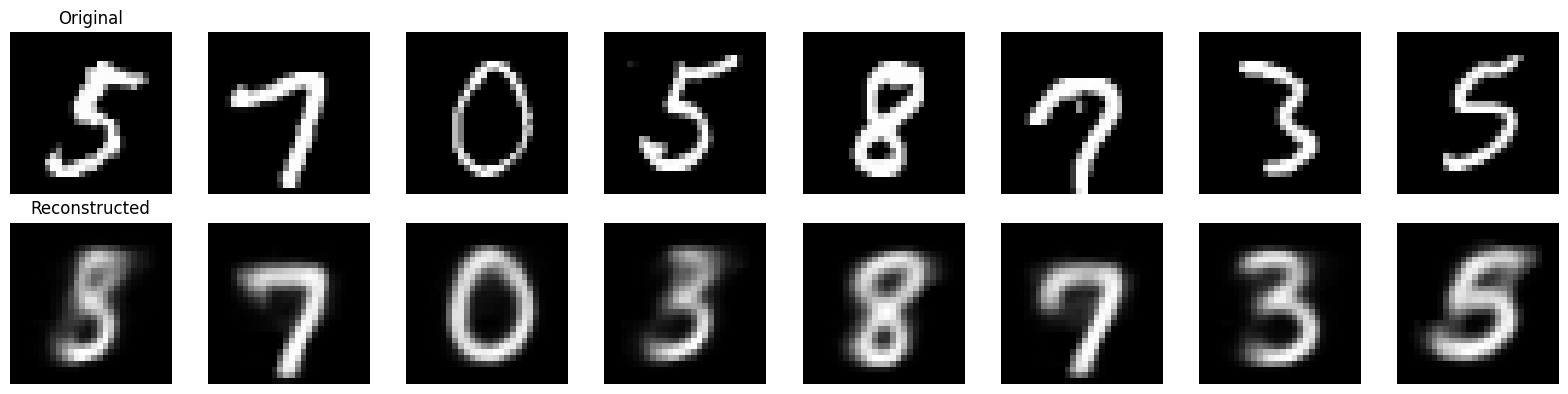

In [78]:
plot_reconstructions(x_np, recon_np, n=8)

https://apxml.com/courses/introduction-autoencoders-feature-learning/chapter-3-how-autoencoders-learn/autoencoder-loss-functions

## Different distances (Wasserstein and such)

## Make sinkhorn in 700 dimensions without autoencoder
